### Setup

In [1]:
#!pip install torch
#!pip install torchvision
#!pip install --upgrade notebook==6.4.12
#!pip install ipywidgets
#!pip install jupyter_contrib_nbextensions
#!jupyter contrib nbextension install --user
#!jupyter nbextension enable --py widgetsnbextension

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#from skimage.feature import local_binary_pattern, hog, graycomatrix, graycoprops
from skimage.color import rgb2gray, rgba2rgb, rgb2hed
##from skimage.io import imread
#from skimage.util import img_as_ubyte
#from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from scipy.stats import spearmanr, pearsonr
import os
import glob
import cv2 
from PIL import Image
from tqdm.notebook import tqdm, trange

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnext50_32x4d
from torch.utils.data import TensorDataset, DataLoader, random_split, Dataset
from sklearn.model_selection import train_test_split
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.device_count())


1


In [3]:
df = pd.read_csv('https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs909/protein_expression_data.csv')

df['specimen_id']=df.VisSpot.apply(lambda x: x.split('-')[2]) #create specimen id field
df['image_id']=df.VisSpot.apply(lambda x: x.split('-')[2])+'_'+df.id #create image id field
train_specimens = ['B1', 'C1', 'D1']
df = df.set_index('image_id').sort_index()
protein_names = ['SMAa', 'CD11b',
       'CD44', 'CD31', 'CDK4', 'YKL40', 'CD11c', 'HIF1a', 'CD24', 'TMEM119',
       'OLIG2', 'GFAP', 'VISTA', 'IBA1', 'CD206', 'PTEN', 'NESTIN', 'TCIRG1',
       'CD74', 'MET', 'P2RY12', 'CD163', 'S100B', 'cMYC', 'pERK', 'EGFR',
       'SOX2', 'HLADR', 'PDGFRa', 'MCT4', 'DNA1', 'DNA3', 'MHCI', 'CD68',
       'CD14', 'KI67', 'CD16', 'SOX10']

df_train = df.loc[df['specimen_id'].isin(train_specimens)]
df_test = df.loc[df['specimen_id'] == 'A1']

image_folder = '/content/patches_256/'

def images_from_ids(im_ids):
    imgs = []
    for im_id in tqdm(im_ids):
        path = os.getcwd()+image_folder+im_id+'.png'
        I = plt.imread(path)
        if I.shape[2] == 4: # it's an RGBA image 
            I = rgba2rgb(I)
        imgs.append(I)
    return np.array(imgs)        

# Resize function
def resize_images(X, new_size=(128, 128)):
    """Resizes all images in X to new_size."""
    n_train, _, _, c = X.shape  # Get original shape
    X_resized = np.zeros((n_train, new_size[0], new_size[1], c), dtype=X.dtype)

    for i in tqdm(range(n_train)):
        X_resized[i] = cv2.resize(X[i], new_size, interpolation=cv2.INTER_AREA)  # Use INTER_AREA for downscaling
    
    return X_resized

def display_results(trues, preds, modelname):
    plt.scatter(trues, preds)

    # Compute scores
    mse = mean_squared_error(trues, preds)
    r2 = r2_score(trues, preds)

    # Fit line of best fit
    coeffs = np.polyfit(trues, preds, 1)
    poly_eq = np.poly1d(coeffs)
    plt.plot(trues, poly_eq(y_test), color="red", label="Best Fit Line")

    # Plot identity line (y = x)
    plt.plot(trues, y_test, color="black", linestyle="--", alpha=0.5, label="Ideal Fit")

    # Add text with R² score
    plt.text(min(trues), max(preds), f"R² = {r2:.4f}", fontsize=12, ha="left", bbox=dict(facecolor="white", alpha=0.7))
    plt.text(min(trues), max(preds), f"MSE = {mse:.4f}", fontsize=12, ha="left", bbox=dict(facecolor="white", alpha=0.7))

    # Labels and title
    plt.xlabel("True CD11b")
    plt.ylabel("Predicted CD11b")
    plt.title(modelname+" True vs Predicted CD11b (First Fold)")
    plt.legend()
    plt.show()

print("Loading training images")
X_train = images_from_ids(df_train.index)
y_train = df_train['CD11b']
print("Loading testing images")
X_test = images_from_ids(df_test.index)
y_test = df_test['CD11b']

#print("Resizing images")
#X_train_resized = resize_images(X_train)
#X_test_resized = resize_images(X_test)


Loading training images


  0%|          | 0/7027 [00:00<?, ?it/s]

Loading testing images


  0%|          | 0/2894 [00:00<?, ?it/s]

### Simple CNN

In [4]:

num_epochs = 10
num_classes = 1
batch_size = 100
learning_rate = 0.001

# Convolutional neural network (two convolutional layers)
class ConvNet(nn.Module):
    def __init__(self, num_classes=1):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.global_avg_pool(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out
    
class AugmentedDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images  # Expect numpy arrays
        self.labels = labels
        self.transform = transform

        

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]  # NumPy array (H, W, C)
        label = self.labels[idx]  # Scalar value

        # Convert image to tensor and change shape to (C, H, W)
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label
    
def plot_results(true_values, predictions, title="True Data vs Model Predictions"): 

    # Convert lists to numpy arrays
    predictions = np.array(predictions).flatten()  # Flatten to 1D
    true_values = np.array(true_values).flatten()  # Flatten to 1D

    # R2 Score
    r2 = r2_score(true_values, predictions)

    # RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))

    # Pearson correlation
    pearson_corr, _ = pearsonr(true_values, predictions)

    # Spearman correlation
    spearman_corr, _ = spearmanr(true_values, predictions)

    # Print the evaluation metrics
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Pearson Correlation: {pearson_corr:.4f}")
    print(f"Spearman Correlation: {spearman_corr:.4f}")

    # Scatter plot: Predictions vs True Values
    plt.figure(figsize=(8, 6))
    plt.scatter(true_values, predictions, alpha=0.5, s=4)
    # Fit line of best fit
    coeffs = np.polyfit(true_values, predictions, 1)
    poly_eq = np.poly1d(coeffs)
    plt.plot(true_values, poly_eq(true_values), color="red", label="Best Fit Line")

    # Plot identity line (y = x)
    plt.plot(true_values, true_values, color="black", linestyle="--", alpha=0.5, label="Ideal Fit")

    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title(title)
    plt.show()

# Full Training Loop 

In [5]:
def full_train_loop(model, train_transforms, num_epochs=10, batch_size=32, learning_rate=0.001):

    # Create TensorDatasets
    train_dataset = AugmentedDataset(X_train, y_train, transform=train_transforms)

    specimens = ['B1', 'C1', 'D1']
    final_results = {}

    for val_specimen in specimens + ['ALL']:
        print(f"\nTraining on {[s for s in specimens if s != val_specimen] if val_specimen != 'ALL' else specimens}, \
            Validating on {val_specimen if val_specimen != 'ALL' else 'None (Training on all)'}")
        
        # Define train and validation sets
        if val_specimen == 'ALL':
            train_subset = train_dataset
            val_indices = []  # No validation set for the final training run
        else:
            train_indices = [i for i, s in enumerate(df_train['specimen_id']) if s != val_specimen]
            val_indices = [i for i, s in enumerate(df_train['specimen_id']) if s == val_specimen]
            train_subset = torch.utils.data.Subset(train_dataset, train_indices)
            val_subset = torch.utils.data.Subset(train_dataset, val_indices) if val_indices else None
        
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False) if val_indices else None
        
        # Initialize model
        model = model.to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()
        
        train_losses, val_losses = [], []
        
        # Training loop
        for epoch in trange(num_epochs, desc="Epoch"):
            model.train()
            running_train_loss = []
            
            for images, labels in tqdm(train_loader, leave=False, desc="Batch"):
                images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_train_loss.append(loss.item())
            
            train_losses.append(np.mean(running_train_loss))
            
            # Validation (if not training on ALL specimens)
            if val_loader:
                model.eval()
                running_val_loss = []
                with torch.no_grad():
                    for images, labels in tqdm(val_loader, leave=False, desc="Validation"):
                        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                        running_val_loss.append(loss.item())
                val_losses.append(np.mean(running_val_loss))
                print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
            else:
                print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_losses[-1]:.4f}")
        
        # Store results
        final_results[val_specimen] = {'train_losses': train_losses, 'val_losses': val_losses if val_loader else None}
        
        # --- Plot Train vs Validation Loss ---
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
        if val_losses:
            plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title(f"Training and Validation Loss ({val_specimen} Validation)")
        plt.show()
        
        # --- Scatter Plot: Predictions vs True Values (for validation runs) ---
        if val_loader:
            predictions, true_values = [], []
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
                    outputs = model(images)
                    predictions.extend(outputs.cpu().numpy().flatten())
                    true_values.extend(labels.cpu().numpy().flatten())
            
            plot_results(true_values, predictions, title=f"Predictions vs True Values ({val_specimen} Validation)")

        if val_specimen == 'ALL':
            # Convert X_test and y_test to PyTorch tensors
            X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)  # (B, C, H, W)
            y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

            # Create DataLoader for test data
            test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
            test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)  # No need to shuffle test data

            # Lists to store predictions and true values
            predictions = []
            true_values = []

            # Set model to evaluation mode
            model.eval()

            # Make predictions on the test set
            with torch.no_grad():
                for images, labels in tqdm(test_loader):
                    images, labels = images.to(device), labels.to(device).float().unsqueeze(1)

                    # Forward pass
                    outputs = model(images)
                    
                    # Store predictions and true values
                    predictions.extend(outputs.cpu().numpy())  # Move to CPU and convert to numpy
                    true_values.extend(labels.cpu().numpy())

            plot_results(true_values, predictions, title='Model Predictions vs True Values (test data)')

    print("Training complete.")

In [6]:
# Apply augmentation only to training data
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # Flip images horizontally
    transforms.RandomRotation(15),           # Random rotation
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1), # Random brightness/contrast changes
    #transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalization
])

#full_train_loop(ConvNet(1), train_transforms, 10)


To beat: R2 -0.6751, RMSE: 1.8588

In [7]:
# Apply augmentation only to training data
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # Flip images horizontally
    transforms.RandomRotation(15),           # Random rotation
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1), # Random brightness/contrast changes
    transforms.RandomErasing(0.2),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))  # Normalization
])

#full_train_loop(ConvNet(1), train_transforms, 10)

Best result so far:

In [8]:
# Apply augmentation only to training data
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # Flip images horizontally
    transforms.RandomRotation(15),           # Random rotation
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1), # Random brightness/contrast changes
    transforms.RandomErasing(0.2),
    # transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))  # Normalization
])

resnet = resnet18()

num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 1)

#full_train_loop(resnet, train_transforms, 10)

In [9]:
resnext = resnext50_32x4d()

num_features = resnext.fc.in_features
resnext.fc = nn.Linear(num_features, 1)  # Single output neuron for regression
#full_train_loop(resnext, train_transforms, 10)

In [10]:
resnext = resnext50_32x4d()

num_features = resnext.fc.in_features
resnext.fc = nn.Linear(num_features, 1)  # Single output neuron for regression
#full_train_loop(resnext, train_transforms, num_epochs=20, batch_size=64)

Best result in validation, not so good in testing

In [11]:
# Apply augmentation only to training data
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # Flip images horizontally
    transforms.RandomRotation(15),           # Random rotation
    transforms.ColorJitter(0.4, 0.2, 0.2, 0.1), # Random brightness/contrast changes
    transforms.RandomErasing(0.2),
    # transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))  # Normalization
])

resnext = resnext50_32x4d(pretrained=True)

num_features = resnext.fc.in_features
resnext.fc = nn.Linear(num_features, 1)  # Single output neuron for regression
#full_train_loop(resnext, train_transforms, num_epochs=20, batch_size=64, learning_rate=0.0001)

/dcs/21/u2101693/modules/cs429/CS909-materials/.venv/lib64/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/dcs/21/u2101693/modules/cs429/CS909-materials/.venv/lib64/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training on ['C1', 'D1'],             Validating on B1


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Batch:   0%|          | 0/92 [00:00<?, ?it/s]

/tmp/dcs-tmp.u2101693/ipykernel_97827/2993876484.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = self.labels[idx]  # Scalar value


Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch [1/1] - Train Loss: 1.5770, Val Loss: 1.6279


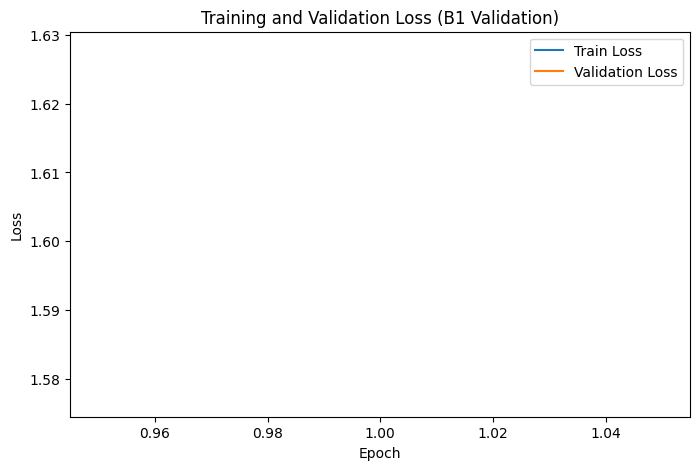

R² Score: 0.2071
RMSE: 1.2725
Pearson Correlation: 0.4727
Spearman Correlation: 0.4719


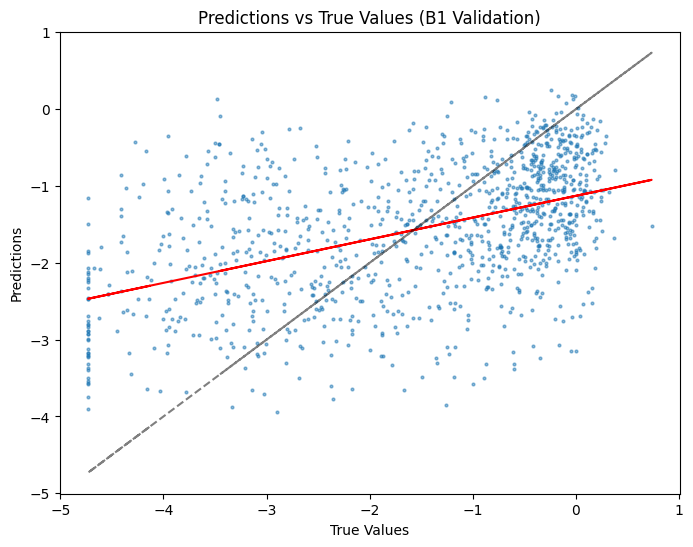


Training on ['B1', 'D1'],             Validating on C1


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Batch:   0%|          | 0/46 [00:00<?, ?it/s]

/tmp/dcs-tmp.u2101693/ipykernel_97827/2993876484.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = self.labels[idx]  # Scalar value


Validation:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch [1/1] - Train Loss: 1.3774, Val Loss: 3.4020


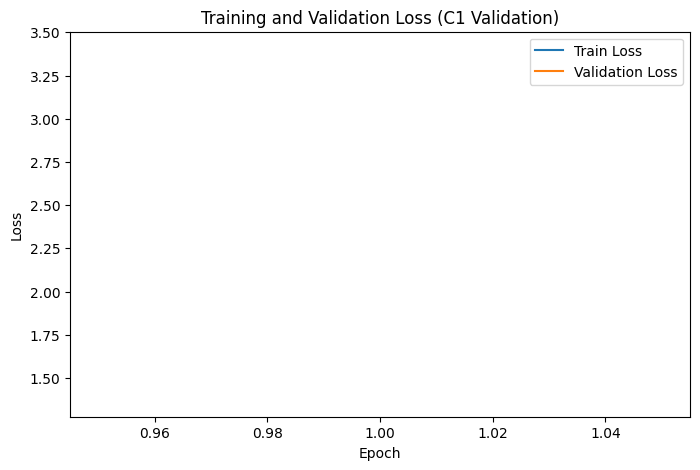

R² Score: -0.7480
RMSE: 1.8510
Pearson Correlation: 0.5139
Spearman Correlation: 0.5305


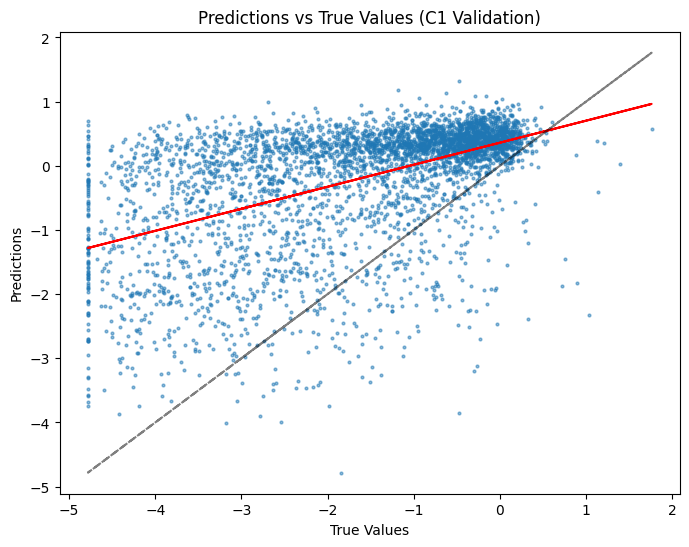


Training on ['B1', 'C1'],             Validating on D1


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Batch:   0%|          | 0/83 [00:00<?, ?it/s]

/tmp/dcs-tmp.u2101693/ipykernel_97827/2993876484.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = self.labels[idx]  # Scalar value


Validation:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch [1/1] - Train Loss: 1.2000, Val Loss: 3.5776


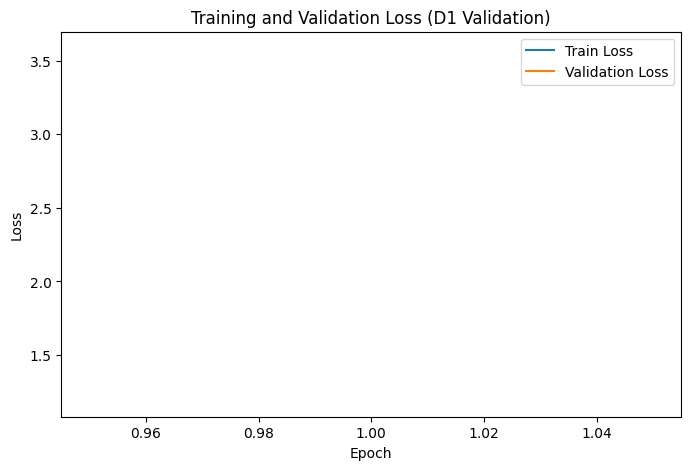

R² Score: -0.2852
RMSE: 1.9099
Pearson Correlation: 0.6360
Spearman Correlation: 0.6490


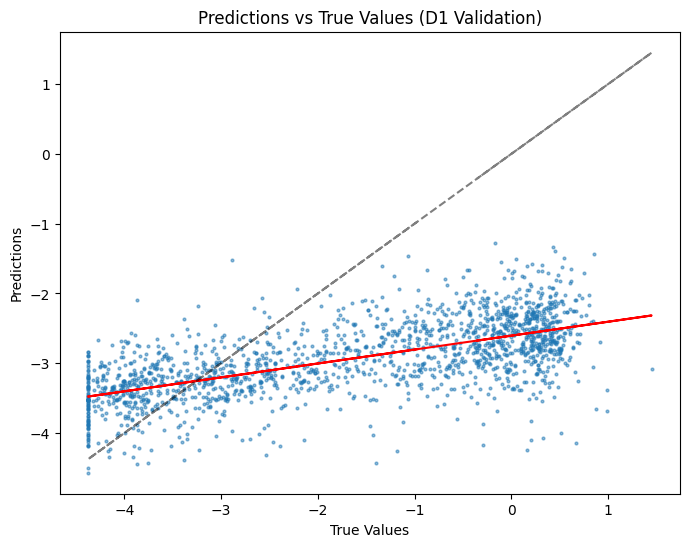


Training on ['B1', 'C1', 'D1'],             Validating on None (Training on all)


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Batch:   0%|          | 0/110 [00:00<?, ?it/s]

/tmp/dcs-tmp.u2101693/ipykernel_97827/2993876484.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = self.labels[idx]  # Scalar value


Epoch [1/1] - Train Loss: 1.2013


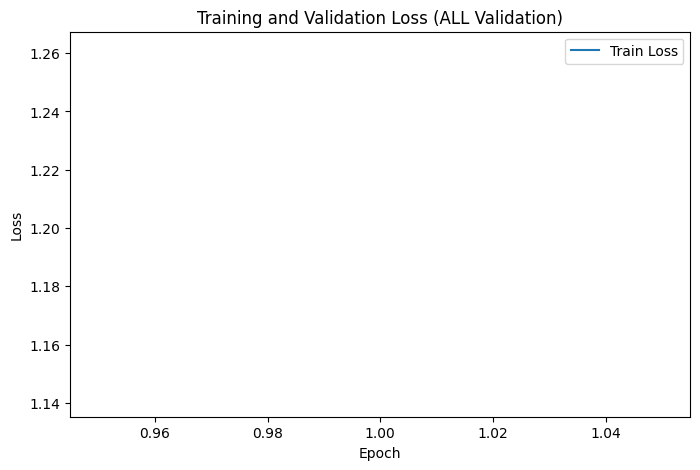

/tmp/dcs-tmp.u2101693/ipykernel_97827/729984017.py:93: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


  0%|          | 0/91 [00:00<?, ?it/s]

R² Score: -0.3088
RMSE: 1.6430
Pearson Correlation: 0.1201
Spearman Correlation: 0.1168


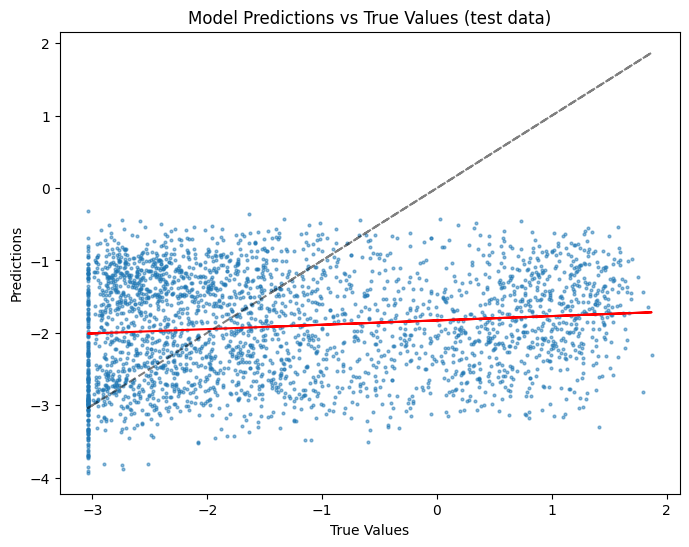

Training complete.


In [12]:
# Apply augmentation only to training data
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # Flip images horizontally
    transforms.RandomRotation(15),           # Random rotation
    transforms.ColorJitter(0.4, 0.2, 0.2, 0.1), # Random brightness/contrast changes
    transforms.RandomErasing(0.2),
    # transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))  # Normalization
])

resnext = resnext50_32x4d(pretrained=True)

num_features = resnext.fc.in_features
resnext.fc = nn.Linear(num_features, 1)  # Single output neuron for regression
full_train_loop(resnext, train_transforms, num_epochs=1, batch_size=64, learning_rate=0.0001)

In [13]:
# Assume y_true and y_pred have shape (num_samples, 38)
def compute_metrics(y_true, y_pred):
    num_proteins = y_true.shape[1]
    results = []

    for i in range(num_proteins):
        true_vals = y_true[:, i]
        pred_vals = y_pred[:, i]

        rmse = root_mean_squared_error(true_vals, pred_vals)
        r2 = r2_score(true_vals, pred_vals)

        # Compute Pearson and Spearman correlation
        pearson_corr, _ = pearsonr(true_vals, pred_vals)
        spearman_corr, _ = spearmanr(true_vals, pred_vals)

        results.append([rmse, pearson_corr, spearman_corr, r2])

    # Convert results to a DataFrame
    df = pd.DataFrame(results, columns=["RMSE", "Pearson", "Spearman", "R2"])
    
    # Compute average and std across proteins
    avg_metrics = df.mean().rename(lambda x: f"{x}_mean")
    std_metrics = df.std().rename(lambda x: f"{x}_std")

    # Combine results
    summary_df = pd.concat([df, avg_metrics.to_frame().T, std_metrics.to_frame().T], ignore_index=True)
    return summary_df



In [ ]:
def full_train_loop_all_proteins(model, train_transforms, num_epochs=10, batch_size=32, learning_rate=0.001):

    # Create TensorDatasets
    train_dataset = AugmentedDataset(X_train, y_train, transform=train_transforms)

    specimens = ['B1', 'C1', 'D1']

    # To store validation fold results
    val_metrics_per_fold = {p: {'RMSE': [], 'Pearson': [], 'Spearman': [], 'R²': []} for p in range(38)}

    for val_specimen in specimens + ['ALL']:
        print(f"\nTraining on {[s for s in specimens if s != val_specimen] if val_specimen != 'ALL' else specimens}, \
            Validating on {val_specimen if val_specimen != 'ALL' else 'None (Training on all)'}")
        
        # Define train and validation sets
        if val_specimen == 'ALL':
            train_subset = train_dataset
            val_indices = []  # No validation set for the final training run
        else:
            train_indices = [i for i, s in enumerate(df_train['specimen_id']) if s != val_specimen]
            val_indices = [i for i, s in enumerate(df_train['specimen_id']) if s == val_specimen]
            train_subset = torch.utils.data.Subset(train_dataset, train_indices)
            val_subset = torch.utils.data.Subset(train_dataset, val_indices) if val_indices else None
        
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False) if val_indices else None
        
        # Initialize model
        model = model.to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()
        
        # Training loop
        for epoch in trange(num_epochs, desc="Epoch"):
            model.train()
            for images, labels in tqdm(train_loader, leave=False, desc="Batch"):
                images, labels = images.to(device), labels.to(device).float()
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # Validation metrics (if applicable)
        if val_loader:
            model.eval()
            all_preds, all_labels = [], []
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device).float()
                    outputs = model(images)
                    all_preds.append(outputs.cpu().numpy())
                    all_labels.append(labels.cpu().numpy())

            all_preds = np.concatenate(all_preds, axis=0)  # Shape: (num_samples, 38)
            all_labels = np.concatenate(all_labels, axis=0)

            # Compute per-protein validation metrics
            for p in range(38):
                y_true, y_pred = all_labels[:, p], all_preds[:, p]
                rmse = root_mean_squared_error(y_true, y_pred)
                r2 = r2_score(y_true, y_pred)
                pearson = pearsonr(y_true, y_pred)[0] if len(set(y_true)) > 1 else np.nan
                spearman = spearmanr(y_true, y_pred)[0] if len(set(y_true)) > 1 else np.nan

                val_metrics_per_fold[p]['RMSE'].append(rmse)
                val_metrics_per_fold[p]['Pearson'].append(pearson)
                val_metrics_per_fold[p]['Spearman'].append(spearman)
                val_metrics_per_fold[p]['R²'].append(r2)

        # Test set evaluation (after training on ALL specimens)
        if val_specimen == 'ALL':
            model.eval()
            test_preds, test_labels = [], []

            test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2),
                                         torch.tensor(y_test, dtype=torch.float32))
            test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

            with torch.no_grad():
                for images, labels in tqdm(test_loader, leave=False, desc="Test Evaluation"):
                    images, labels = images.to(device), labels.to(device).float()
                    outputs = model(images)
                    test_preds.append(outputs.cpu().numpy())
                    test_labels.append(labels.cpu().numpy())

            test_preds = np.concatenate(test_preds, axis=0)
            test_labels = np.concatenate(test_labels, axis=0)

            test_results = {}

            # Record validation results
            for p in range(38):
                y_true, y_pred = test_labels[:, p], test_preds[:, p]
                test_results[p] = {
                    'RMSE': root_mean_squared_error(y_true, y_pred),
                    'Pearson': pearsonr(y_true, y_pred)[0] if len(set(y_true)) > 1 else np.nan,
                    'Spearman': spearmanr(y_true, y_pred)[0] if len(set(y_true)) > 1 else np.nan,
                    'R²': r2_score(y_true, y_pred)
                }

    # Final results
    final_data = []
    for p in range(38):
        row = {
            'Protein': protein_names[p],
            'Test RMSE': test_results[p]['RMSE'],
            'Test Pearson': test_results[p]['Pearson'],
            'Test Spearman': test_results[p]['Spearman'],
            'Test R²': test_results[p]['R²'],
            'Val Mean RMSE': np.mean(val_metrics_per_fold[p]['RMSE']),
            'Val Std RMSE': np.std(val_metrics_per_fold[p]['RMSE']),
            'Val Mean Pearson': np.nanmean(val_metrics_per_fold[p]['Pearson']),
            'Val Std Pearson': np.nanstd(val_metrics_per_fold[p]['Pearson']),
            'Val Mean Spearman': np.nanmean(val_metrics_per_fold[p]['Spearman']),
            'Val Std Spearman': np.nanstd(val_metrics_per_fold[p]['Spearman']),
            'Val Mean R²': np.nanmean(val_metrics_per_fold[p]['R²']),
            'Val Std R²': np.nanstd(val_metrics_per_fold[p]['R²']),
        }
        final_data.append(row)

    results_df = pd.DataFrame(final_data)
    return results_df

In [15]:
resnext.fc = nn.Linear(num_features, 38)

y_train = df_train[protein_names].to_numpy()
y_test = df_test[protein_names].to_numpy()
# print(y_train.to_numpy().shape)

full_train_loop_all_proteins(resnext, train_transforms, num_epochs=1, batch_size=64, learning_rate=0.0001)



Training on ['C1', 'D1'],             Validating on B1


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Batch:   0%|          | 0/92 [00:00<?, ?it/s]


Training on ['B1', 'D1'],             Validating on C1


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

...


Training on ['B1', 'C1', 'D1'],             Validating on None (Training on all)


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Batch:   0%|          | 0/110 [00:00<?, ?it/s]

Test Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

,Protein,Test RMSE,Test Pearson,Test Spearman,Test R²,Val Mean RMSE,Val Std RMSE,Val Mean Pearson,Val Std Pearson,Val Mean Spearman,Val Std Spearman,Val Mean R²,Val Std R²
0,Protein_1,0.822874,0.130344,0.068423,-0.056092,0.773360,0.113339,0.037793,0.122096,0.009792,0.132424,-0.433707,0.545422
1,Protein_2,1.740447,0.083061,0.086348,-0.468630,1.302625,0.199439,0.653300,0.026712,0.668748,0.006309,0.251425,0.123375
2,Protein_3,0.830729,0.108321,0.259003,-1.756909,0.833036,0.263369,0.369222,0.065870,0.352800,0.073154,-0.148137,0.374665
3,Protein_4,0.560267,0.092507,0.074288,-0.026984,0.548766,0.049597,0.070630,0.032162,0.010731,0.028530,-0.170386,0.125910
4,Protein_5,0.892223,0.622790,0.650811,0.376283,0.957406,0.108863,0.493186,0.174243,0.318944,0.271482,0.189384,0.247109
5,Protein_6,0.381461,0.237853,0.200637,-0.336295,0.433039,0.074122,0.486749,0.103611,0.304835,0.156142,0.119844,0.177590
6,Protein_7,0.929896,0.289891,0.295554,0.043651,0.914419,0.126709,0.111445,0.051406,0.145481,0.050010,-0.081236,0.108846
7,Protein_8,0.743165,0.208316,0.104274,-0.188286,0.808811,0.073318,0.080028,0.136224,0.013834,0.083381,-0.111622,0.107514
8,Protein_9,1.275424,-0.045731,-0.019354,-0.296085,1.251970,0.087480,0.151593,0.018603,0.133640,0.028856,-0.079445,0.090349
9,Protein_10,1.283638,0.557068,0.297663,0.307043,1.299816,0.194787,0.548912,0.119715,0.448814,0.177592,0.179108,0.125304
